In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import time

print("TensorFlow Version:", tf.__version__)

print("\nAvailable GPU:")
print(tf.config.list_physical_devices('GPU'))

TensorFlow Version: 2.20.0

Available GPU:
[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [3]:
(X_train, y_train), (X_test, y_test) = tf.keras.datasets.cifar10.load_data()

print("Dataset loaded successfully!")

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 1728s 10us/step
Dataset loaded successfully!


In [4]:
class_names = [
    'Airplane',
    'Automobile',
    'Bird',
    'Cat',
    'Deer',
    'Dog',
    'Frog',
    'Horse',
    'Ship',
    'Truck'
]
print("Training images shape:", X_train.shape)
print("Training labels shape:", y_train.shape)

print("Testing images shape:", X_test.shape)
print("Testing labels shape:", y_test.shape)

Training images shape: (50000, 32, 32, 3)
Training labels shape: (50000, 1)
Testing images shape: (10000, 32, 32, 3)
Testing labels shape: (10000, 1)


In [5]:
# Normalize pixel values from [0, 255] to [0, 1]
X_train = X_train.astype('float32') / 255.0
X_test = X_test.astype('float32') / 255.0

print("Minimum pixel value:", X_train.min())
print("Maximum pixel value:", X_train.max())

Minimum pixel value: 0.0
Maximum pixel value: 1.0


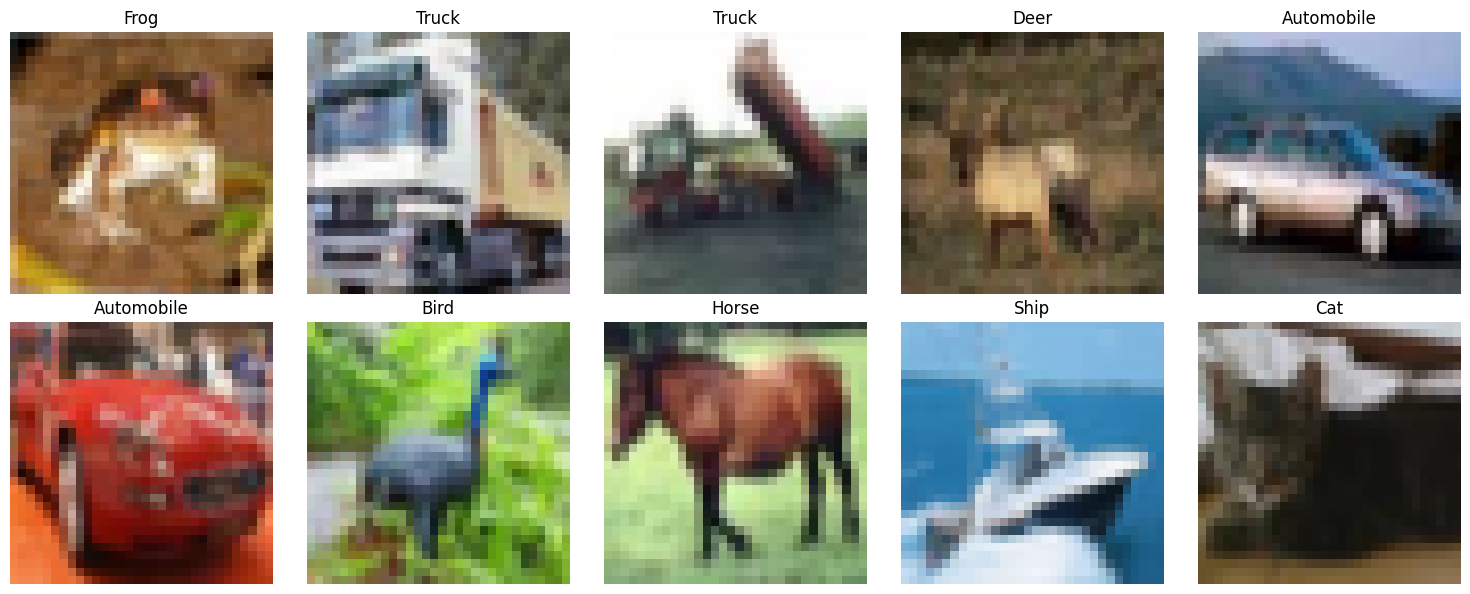

In [ ]:
plt.figure(figsize=(15, 6))

for i in range(10):
    plt.subplot(2, 5, i + 1)

    plt.imshow(X_train[i])
    plt.title(class_names[y_train[i][0]])
    plt.axis('off')

plt.tight_layout()
plt.savefig(
    "Figures/sample_cifar10_images.pdf",
    format="pdf",
    dpi=600,
    bbox_inches="tight"
)
plt.show()

In [ ]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input
from tensorflow.keras.layers import GlobalAveragePooling2D
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam

# Input layer
inputs = Input(shape=(32, 32, 3))

# Load VGG16 with pretrained ImageNet weights
base_model = VGG16(
    weights='imagenet',
    include_top=False,
    input_shape=(32, 32, 3)
)

# Freeze the convolutional base
base_model.trainable = False

# Extract features
x = base_model(inputs, training=False)

# Global Average Pooling
x = GlobalAveragePooling2D()(x)

# Dense layer with ReLU activation
x = Dense(128, activation='relu')(x)

# Output layer with Softmax activation
outputs = Dense(10, activation='softmax')(x)

# Create final model
vgg16_model = Model(inputs=inputs, outputs=outputs)

# Display model architecture
vgg16_model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg16 (Functional)              │ (None, 1, 1, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,781,642 (56.39 MB)

 Trainable params: 66,954 (261.54 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [ ]:
vgg16_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("Total Parameters:", vgg16_model.count_params())

print(
    "Trainable Parameters:",
    np.sum([
        tf.keras.backend.count_params(w)
        for w in vgg16_model.trainable_weights
    ])
)

print(
    "Non-Trainable Parameters:",
    np.sum([
        tf.keras.backend.count_params(w)
        for w in vgg16_model.non_trainable_weights
    ])
)

Total Parameters: 14781642
Trainable Parameters: 66954
Non-Trainable Parameters: 14714688


In [ ]:
start_time = time.time()

history_vgg16 = vgg16_model.fit(
    X_train,
    y_train,
    validation_split=0.1,
    epochs=10,
    batch_size=32,
    verbose=1
)

vgg16_training_time = time.time() - start_time

print("\n===================================")
print("VGG16 Training Completed")
print("===================================")
print(f"Training Time: {vgg16_training_time:.2f} seconds")
print(f"Training Time: {vgg16_training_time / 60:.2f} minutes")

Epoch 1/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 20s 11ms/step - accuracy: 0.5175 - loss: 1.3816 - val_accuracy: 0.5776 - val_loss: 1.2054
Epoch 2/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - accuracy: 0.5810 - loss: 1.1947 - val_accuracy: 0.5830 - val_loss: 1.1717
Epoch 3/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 12s 9ms/step - accuracy: 0.6016 - loss: 1.1396 - val_accuracy: 0.5952 - val_loss: 1.1391
Epoch 4/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 12s 9ms/step - accuracy: 0.6167 - loss: 1.0979 - val_accuracy: 0.6068 - val_loss: 1.1291
Epoch 5/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 12s 9ms/step - accuracy: 0.6295 - loss: 1.0643 - val_accuracy: 0.6080 - val_loss: 1.1104
Epoch 6/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 12s 9ms/step - accuracy: 0.6380 - loss: 1.0322 - val_accuracy: 0.6102 - val_loss: 1.1029
Epoch 7/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 12s 9ms/step - accuracy: 0.6495 - loss: 1.0070 - val_accuracy: 0.6160 - val_loss: 1.1012
Epoch 8/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 12s 9ms/step - accuracy: 0.6581 - loss: 

In [ ]:
# Evaluate VGG16 before fine-tuning

test_loss_before, test_accuracy_before = vgg16_model.evaluate(
    X_test,
    y_test,
    verbose=1
)

print("\n===== VGG16 Before Fine-Tuning =====")
print(f"Test Loss: {test_loss_before:.4f}")
print(f"Test Accuracy: {test_accuracy_before:.4f}")
print(f"Test Accuracy: {test_accuracy_before * 100:.2f}%")

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.6075 - loss: 1.1455

===== VGG16 Before Fine-Tuning =====
Test Loss: 1.1455
Test Accuracy: 0.6075
Test Accuracy: 60.75%


In [ ]:
# Freeze all layers first
base_model.trainable = False

# Unfreeze only the last convolutional block (Block 5)
for layer in base_model.layers:
    if layer.name.startswith('block5'):
        layer.trainable = True

# Check which layers are trainable
for layer in base_model.layers:
    print(layer.name, layer.trainable)

input_layer_3 False
block1_conv1 False
block1_conv2 False
block1_pool False
block2_conv1 False
block2_conv2 False
block2_pool False
block3_conv1 False
block3_conv2 False
block3_conv3 False
block3_pool False
block4_conv1 False
block4_conv2 False
block4_conv3 False
block4_pool False
block5_conv1 True
block5_conv2 True
block5_conv3 True
block5_pool True


In [ ]:
# Recompile with a smaller learning rate for fine-tuning

vgg16_model.compile(
    optimizer=Adam(learning_rate=0.00001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Fine-tune VGG16

start_time = time.time()

history_vgg16_finetune = vgg16_model.fit(
    X_train,
    y_train,
    validation_split=0.1,
    epochs=5,
    batch_size=32,
    verbose=1
)

vgg16_finetuning_time = time.time() - start_time

print("\n===================================")
print("VGG16 Fine-Tuning Completed")
print("===================================")
print(f"Fine-Tuning Time: {vgg16_finetuning_time:.2f} seconds")
print(f"Fine-Tuning Time: {vgg16_finetuning_time / 60:.2f} minutes")

Epoch 1/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 25s 15ms/step - accuracy: 0.7022 - loss: 0.8490 - val_accuracy: 0.6656 - val_loss: 0.9643
Epoch 2/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 17s 12ms/step - accuracy: 0.7578 - loss: 0.6867 - val_accuracy: 0.6880 - val_loss: 0.9322
Epoch 3/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 17s 12ms/step - accuracy: 0.7957 - loss: 0.5850 - val_accuracy: 0.6994 - val_loss: 0.8996
Epoch 4/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 18s 12ms/step - accuracy: 0.8273 - loss: 0.4983 - val_accuracy: 0.7090 - val_loss: 0.9094
Epoch 5/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 18s 13ms/step - accuracy: 0.8546 - loss: 0.4264 - val_accuracy: 0.7150 - val_loss: 0.8971

VGG16 Fine-Tuning Completed
Fine-Tuning Time: 96.55 seconds
Fine-Tuning Time: 1.61 minutes


In [ ]:
test_loss_after, test_accuracy_after = vgg16_model.evaluate(
    X_test,
    y_test,
    verbose=1
)

print("\n===== VGG16 After Fine-Tuning =====")
print(f"Test Loss: {test_loss_after:.4f}")
print(f"Test Accuracy: {test_accuracy_after:.4f}")
print(f"Test Accuracy: {test_accuracy_after * 100:.2f}%")

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.7044 - loss: 0.9168

===== VGG16 After Fine-Tuning =====
Test Loss: 0.9168
Test Accuracy: 0.7044
Test Accuracy: 70.44%


In [ ]:
print("\n==========================================")
print("VGG16: BEFORE vs AFTER FINE-TUNING")
print("==========================================")

print(f"Before Fine-Tuning : {test_accuracy_before * 100:.2f}%")
print(f"After Fine-Tuning  : {test_accuracy_after * 100:.2f}%")

improvement = (test_accuracy_after - test_accuracy_before) * 100

print(f"Improvement        : {improvement:.2f}%")


VGG16: BEFORE vs AFTER FINE-TUNING
Before Fine-Tuning : 60.75%
After Fine-Tuning  : 70.44%
Improvement        : 9.69%


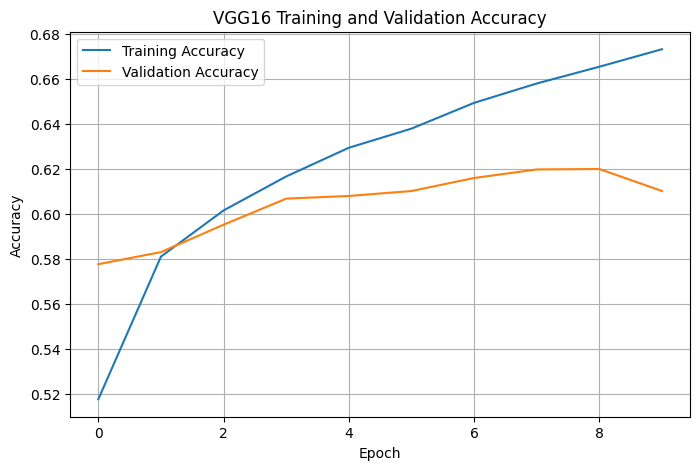

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(
    history_vgg16.history['accuracy'],
    label='Training Accuracy'
)

plt.plot(
    history_vgg16.history['val_accuracy'],
    label='Validation Accuracy'
)

plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('VGG16 Training and Validation Accuracy')
plt.legend()
plt.grid(True)
plt.savefig(
    "Figures/vgg16_training_validation_accuracy.eps",
    format="eps",
    dpi=600,
    bbox_inches="tight"
)
plt.show()

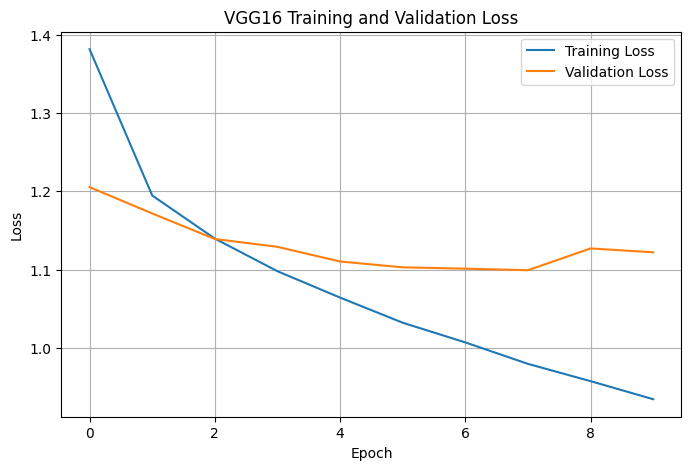

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(
    history_vgg16.history['loss'],
    label='Training Loss'
)

plt.plot(
    history_vgg16.history['val_loss'],
    label='Validation Loss'
)

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('VGG16 Training and Validation Loss')
plt.legend()
plt.grid(True)
plt.savefig(
    "Figures/vgg16_training_validation_loss.eps",
    format="eps",
    dpi=600,
    bbox_inches="tight"
)
plt.show()

In [ ]:
# Generate predictions on test set

y_pred_prob = vgg16_model.predict(
    X_test,
    batch_size=32,
    verbose=1
)

# Convert probabilities to class labels
y_pred = np.argmax(y_pred_prob, axis=1)

# Convert true labels from (10000, 1) to (10000,)
y_true = y_test.flatten()

print("Predictions generated successfully.")
print("Predicted labels shape:", y_pred.shape)
print("True labels shape:", y_true.shape)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step
Predictions generated successfully.
Predicted labels shape: (10000,)
True labels shape: (10000,)


In [ ]:
from sklearn.metrics import classification_report

print("===== VGG16 Classification Report =====")

print(
    classification_report(
        y_true,
        y_pred,
        target_names=class_names,
        digits=4
    )
)

===== VGG16 Classification Report =====
              precision    recall  f1-score   support

    Airplane     0.7332    0.8050    0.7674      1000
  Automobile     0.8171    0.7730    0.7945      1000
        Bird     0.6628    0.6250    0.6433      1000
         Cat     0.5688    0.4630    0.5105      1000
        Deer     0.6629    0.6530    0.6579      1000
         Dog     0.5425    0.6760    0.6020      1000
        Frog     0.7190    0.7550    0.7366      1000
       Horse     0.7646    0.7600    0.7623      1000
        Ship     0.7943    0.8380    0.8156      1000
       Truck     0.8009    0.6960    0.7448      1000

    accuracy                         0.7044     10000
   macro avg     0.7066    0.7044    0.7035     10000
weighted avg     0.7066    0.7044    0.7035     10000



In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score

precision = precision_score(
    y_true,
    y_pred,
    average='weighted'
)

recall = recall_score(
    y_true,
    y_pred,
    average='weighted'
)

f1 = f1_score(
    y_true,
    y_pred,
    average='weighted'
)

print("===== VGG16 Overall Metrics =====")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1-score  : {f1:.4f}")

===== VGG16 Overall Metrics =====
Precision : 0.7066
Recall    : 0.7044
F1-score  : 0.7035


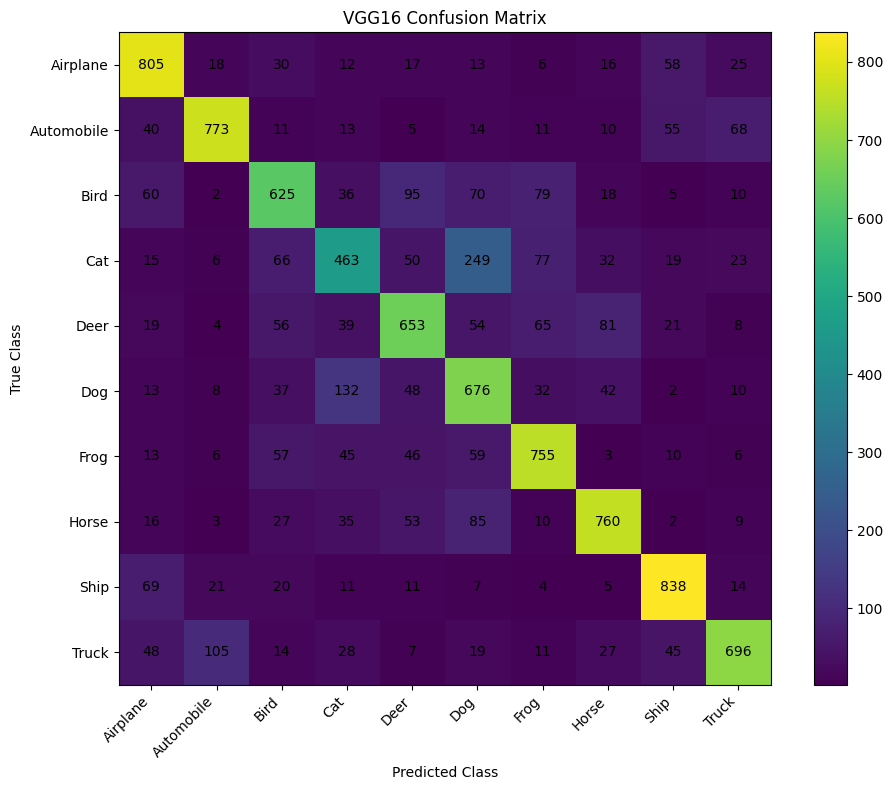

In [ ]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10, 8))

plt.imshow(cm)

plt.title('VGG16 Confusion Matrix')
plt.xlabel('Predicted Class')
plt.ylabel('True Class')

plt.xticks(
    ticks=np.arange(10),
    labels=class_names,
    rotation=45,
    ha='right'
)

plt.yticks(
    ticks=np.arange(10),
    labels=class_names
)

# Display values inside cells
for i in range(10):
    for j in range(10):
        plt.text(
            j,
            i,
            cm[i, j],
            ha='center',
            va='center'
        )

plt.colorbar()
plt.tight_layout()
plt.savefig(
    "Figures/vgg16_confusion_matrix.pdf",
    format="pdf",
    dpi=600,
    bbox_inches="tight"
)
plt.show()

Total misclassified images: 2956


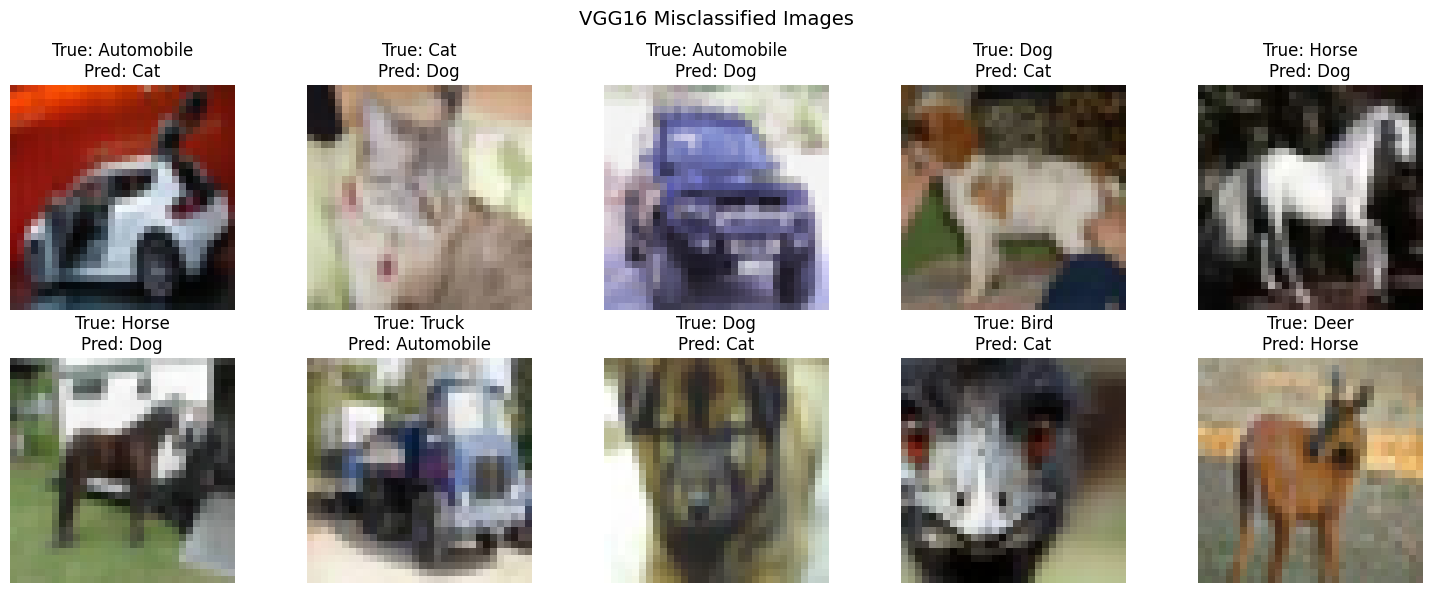

In [ ]:

# Get predictions
y_pred_prob = vgg16_model.predict(
    X_test,
    verbose=0
)

# Convert probabilities to class labels
y_pred_classes = np.argmax(
    y_pred_prob,
    axis=1
)

# True labels
y_true = y_test.flatten()

# Find incorrectly classified images
misclassified_indices = np.where(
    y_pred_classes != y_true
)[0]

print("Total misclassified images:",
      len(misclassified_indices))


# ------------------------------------------------------------
# Display first 10 misclassified images
# ------------------------------------------------------------

num_images = min(10, len(misclassified_indices))

plt.figure(figsize=(15, 6))

for i in range(num_images):

    idx = misclassified_indices[i]

    plt.subplot(2, 5, i + 1)

    plt.imshow(X_test[idx])

    plt.title(
        f"True: {class_names[y_true[idx]]}\n"
        f"Pred: {class_names[y_pred_classes[idx]]}"
    )

    plt.axis('off')

plt.suptitle(
    'VGG16 Misclassified Images',
    fontsize=14
)

plt.tight_layout()

# Save as EPS
plt.savefig(
    "Figures/vgg16_misclassified_images.pdf",
    format="pdf",
    dpi=600,
    bbox_inches="tight"
)

plt.show()
plt.close()

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, AveragePooling2D, Flatten, Dense


# Build LeNet-5
lenet5 = Sequential([
    Conv2D(6, kernel_size=(5, 5), activation='tanh',
           padding='same', input_shape=(32, 32, 3)),
    AveragePooling2D(pool_size=(2, 2)),

    Conv2D(16, kernel_size=(5, 5), activation='tanh'),
    AveragePooling2D(pool_size=(2, 2)),

    Conv2D(120, kernel_size=(5, 5), activation='tanh'),

    Flatten(),

    Dense(84, activation='tanh'),
    Dense(10, activation='softmax')
])

# Compile
lenet5.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Display model information
lenet5.summary()

# Number of parameters
lenet_params = lenet5.count_params()

# Train
start_time = time.time()

lenet_history = lenet5.fit(
    X_train,
    y_train,
    validation_split=0.1,
    epochs=10,
    batch_size=32,
    verbose=1
)

lenet_training_time = time.time() - start_time

# Test evaluation
lenet_test_loss, lenet_test_accuracy = lenet5.evaluate(
    X_test,
    y_test,
    verbose=0
)

# Final results
print("\n================================")
print("LeNet-5 RESULTS")
print("================================")
print(f"Parameters      : {lenet_params:,}")
print(f"Test Accuracy   : {lenet_test_accuracy * 100:.2f}%")
print(f"Training Time   : {lenet_training_time:.2f} seconds")
print(f"Training Time   : {lenet_training_time / 60:.2f} minutes")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 6)      │           456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d               │ (None, 16, 16, 6)      │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 12, 12, 16)     │         2,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_1             │ (None, 6, 6, 16)       │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 2, 2, 120)      │        48,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 480)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 84)             │        40,404 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │           850 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 92,246 (360.34 KB)

 Trainable params: 92,246 (360.34 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.3676 - loss: 1.7916 - val_accuracy: 0.4154 - val_loss: 1.6488
Epoch 2/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.4442 - loss: 1.5700 - val_accuracy: 0.4692 - val_loss: 1.5225
Epoch 3/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.4809 - loss: 1.4710 - val_accuracy: 0.4878 - val_loss: 1.4629
Epoch 4/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.4999 - loss: 1.4094 - val_accuracy: 0.5004 - val_loss: 1.4242
Epoch 5/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.5235 - loss: 1.3493 - val_accuracy: 0.5150 - val_loss: 1.3846
Epoch 6/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.5423 - loss: 1.2985 - val_accuracy: 0.5160 - val_loss: 1.3991
Epoch 7/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.5594 - loss: 1.2472 - val_accuracy: 0.5286 - val_loss: 1.3384
Epoch 8/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.5766 - loss: 1.2016 -

In [ ]:
from tensorflow.keras.layers import Dropout,MaxPooling2D

# Build AlexNet
alexnet = Sequential([
    # Block 1
    Conv2D(96, kernel_size=(3, 3), padding='same',
           activation='relu', input_shape=(32, 32, 3)),
    MaxPooling2D(pool_size=(2, 2)),

    # Block 2
    Conv2D(256, kernel_size=(3, 3), padding='same',
           activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),

    # Block 3
    Conv2D(384, kernel_size=(3, 3), padding='same',
           activation='relu'),

    # Block 4
    Conv2D(384, kernel_size=(3, 3), padding='same',
           activation='relu'),

    # Block 5
    Conv2D(256, kernel_size=(3, 3), padding='same',
           activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),

    # Classifier
    Flatten(),
    Dense(4096, activation='relu'),
    Dropout(0.5),

    Dense(4096, activation='relu'),
    Dropout(0.5),

    Dense(10, activation='softmax')
])

# Compile
alexnet.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Display model information
alexnet.summary()

# Number of parameters
alexnet_params = alexnet.count_params()

# Train
start_time = time.time()

alexnet_history = alexnet.fit(
    X_train,
    y_train,
    validation_split=0.1,
    epochs=10,
    batch_size=32,
    verbose=1
)

alexnet_training_time = time.time() - start_time

# Test evaluation
alexnet_test_loss, alexnet_test_accuracy = alexnet.evaluate(
    X_test,
    y_test,
    verbose=0
)

# Final results
print("\n================================")
print("AlexNet RESULTS")
print("================================")
print(f"Parameters      : {alexnet_params:,}")
print(f"Test Accuracy   : {alexnet_test_accuracy * 100:.2f}%")
print(f"Training Time   : {alexnet_training_time:.2f} seconds")
print(f"Training Time   : {alexnet_training_time / 60:.2f} minutes")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 32, 32, 96)     │         2,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 96)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 16, 16, 256)    │       221,440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 8, 8, 384)      │       885,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 8, 8, 384)      │     1,327,488 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 8, 8, 256)      │       884,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 4096)           │    16,781,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 4096)           │    16,781,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 10)             │        40,970 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 36,925,322 (140.86 MB)

 Trainable params: 36,925,322 (140.86 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 43s 26ms/step - accuracy: 0.0997 - loss: 2.3036 - val_accuracy: 0.0976 - val_loss: 2.3030
Epoch 2/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 30s 21ms/step - accuracy: 0.0990 - loss: 2.3028 - val_accuracy: 0.0950 - val_loss: 2.3031
Epoch 3/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 31s 22ms/step - accuracy: 0.1001 - loss: 2.3028 - val_accuracy: 0.0958 - val_loss: 2.3025
Epoch 4/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 30s 21ms/step - accuracy: 0.1004 - loss: 2.3028 - val_accuracy: 0.0970 - val_loss: 2.3028
Epoch 5/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 30s 21ms/step - accuracy: 0.0989 - loss: 2.3028 - val_accuracy: 0.0986 - val_loss: 2.3027
Epoch 6/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 30s 21ms/step - accuracy: 0.0967 - loss: 2.3028 - val_accuracy: 0.1024 - val_loss: 2.3027
Epoch 7/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 30s 21ms/step - accuracy: 0.0999 - loss: 2.3028 - val_accuracy: 0.0976 - val_loss: 2.3028
Epoch 8/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 30s 21ms/step - accuracy: 0.0978 -

In [ ]:
from tensorflow.keras.layers import (
    GlobalAveragePooling2D, Concatenate
)
from tensorflow.keras.models import Model

# Inception Module
def inception_module(x, filters):

    f1, f3_reduce, f3, f5_reduce, f5, pool_proj = filters

    # Branch 1: 1x1 convolution
    branch1 = Conv2D(
        f1, (1, 1),
        padding='same',
        activation='relu'
    )(x)

    # Branch 2: 1x1 -> 3x3
    branch2 = Conv2D(
        f3_reduce, (1, 1),
        padding='same',
        activation='relu'
    )(x)

    branch2 = Conv2D(
        f3, (3, 3),
        padding='same',
        activation='relu'
    )(branch2)

    # Branch 3: 1x1 -> 5x5
    branch3 = Conv2D(
        f5_reduce, (1, 1),
        padding='same',
        activation='relu'
    )(x)

    branch3 = Conv2D(
        f5, (5, 5),
        padding='same',
        activation='relu'
    )(branch3)

    # Branch 4: MaxPool -> 1x1
    branch4 = MaxPooling2D(
        (3, 3),
        strides=(1, 1),
        padding='same'
    )(x)

    branch4 = Conv2D(
        pool_proj, (1, 1),
        padding='same',
        activation='relu'
    )(branch4)

    # Concatenate all branches
    output = Concatenate(axis=-1)(
        [branch1, branch2, branch3, branch4]
    )

    return output


# Build GoogLeNet
inputs = Input(shape=(32, 32, 3))

x = Conv2D(
    64, (3, 3),
    padding='same',
    activation='relu'
)(inputs)

x = MaxPooling2D(
    (2, 2),
    strides=2
)(x)


# Inception 3a
x = inception_module(
    x,
    (64, 96, 128, 16, 32, 32)
)

# Inception 3b
x = inception_module(
    x,
    (128, 128, 192, 32, 96, 64)
)

x = MaxPooling2D(
    (2, 2),
    strides=2
)(x)


# Inception 4a
x = inception_module(
    x,
    (192, 96, 208, 16, 48, 64)
)

# Inception 4b
x = inception_module(
    x,
    (160, 112, 224, 24, 64, 64)
)

# Inception 4c
x = inception_module(
    x,
    (128, 128, 256, 24, 64, 64)
)

x = MaxPooling2D(
    (2, 2),
    strides=2
)(x)


# Inception 5a
x = inception_module(
    x,
    (256, 160, 320, 32, 128, 128)
)

# Inception 5b
x = inception_module(
    x,
    (384, 192, 384, 48, 128, 128)
)

# Global Average Pooling
x = GlobalAveragePooling2D()(x)

# Output
outputs = Dense(
    10,
    activation='softmax'
)(x)

# Create model
googlenet = Model(
    inputs=inputs,
    outputs=outputs
)

# Compile
googlenet.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Model information
googlenet.summary()

# Number of parameters
googlenet_params = googlenet.count_params()

# Train
start_time = time.time()

googlenet_history = googlenet.fit(
    X_train,
    y_train,
    validation_split=0.1,
    epochs=10,
    batch_size=32,
    verbose=1
)

googlenet_training_time = time.time() - start_time

# Test evaluation
googlenet_test_loss, googlenet_test_accuracy = googlenet.evaluate(
    X_test,
    y_test,
    verbose=0
)

# Final results
print("\n================================")
print("GoogLeNet RESULTS")
print("================================")
print(f"Parameters      : {googlenet_params:,}")
print(f"Test Accuracy   : {googlenet_test_accuracy * 100:.2f}%")
print(f"Training Time   : {googlenet_training_time:.2f} seconds")
print(f"Training Time   : {googlenet_training_time / 60:.2f} minutes")

Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_6       │ (None, 32, 32, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_9 (Conv2D)   │ (None, 32, 32,    │      1,792 │ input_layer_6[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_3     │ (None, 16, 16,    │          0 │ conv2d_9[0][0]    │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_11 (Conv2D)  │ (None, 16, 16,    │      6,240 │ max_pooling2d_3[… │
│                     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_13 (Conv2D)  │ (None, 16, 16,    │      1,040 │ max_pooling2d_3[… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_4     │ (None, 16, 16,    │          0 │ max_pooling2d_3[… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_10 (Conv2D)  │ (None, 16, 16,    │      4,160 │ max_pooling2d_3[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_12 (Conv2D)  │ (None, 16, 16,    │    110,720 │ conv2d_11[0][0]   │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_14 (Conv2D)  │ (None, 16, 16,    │     12,832 │ conv2d_13[0][0]   │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_15 (Conv2D)  │ (None, 16, 16,    │      2,080 │ max_pooling2d_4[… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 16, 16,    │          0 │ conv2d_10[0][0],  │
│ (Concatenate)       │ 256)              │            │ conv2d_12[0][0],  │
│                     │                   │            │ conv2d_14[0][0],  │
│                     │                   │            │ conv2d_15[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_17 (Conv2D)  │ (None, 16, 16,    │     32,896 │ concatenate[0][0] │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_19 (Conv2D)  │ (None, 16, 16,    │      8,224 │ concatenate[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_5     │ (None, 16, 16,    │          0 │ concatenate[0][0] │
│ (MaxPooling2D)      │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_16 (Conv2D)  │ (None, 16, 16,    │     32,896 │ concatenate[0][0] │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_18 (Conv2D)  │ (None, 16, 16,    │    221,376 │ conv2d_17[0][0]   │
│                     │ 192)              │            │                 

 Total params: 4,176,506 (15.93 MB)

 Trainable params: 4,176,506 (15.93 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 88s 45ms/step - accuracy: 0.2731 - loss: 1.9068 - val_accuracy: 0.4412 - val_loss: 1.5079
Epoch 2/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 41s 29ms/step - accuracy: 0.5009 - loss: 1.3640 - val_accuracy: 0.5724 - val_loss: 1.1912
Epoch 3/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 40s 28ms/step - accuracy: 0.5945 - loss: 1.1277 - val_accuracy: 0.5816 - val_loss: 1.2192
Epoch 4/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 40s 28ms/step - accuracy: 0.6578 - loss: 0.9649 - val_accuracy: 0.6950 - val_loss: 0.8851
Epoch 5/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 40s 28ms/step - accuracy: 0.7040 - loss: 0.8451 - val_accuracy: 0.7128 - val_loss: 0.8355
Epoch 6/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 40s 28ms/step - accuracy: 0.7367 - loss: 0.7475 - val_accuracy: 0.7288 - val_loss: 0.7939
Epoch 7/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 40s 28ms/step - accuracy: 0.7622 - loss: 0.6720 - val_accuracy: 0.7222 - val_loss: 0.8337
Epoch 8/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 40s 28ms/step - accuracy: 0.7868 -

In [ ]:
from tensorflow.keras.applications import ResNet50

# Input
inputs = Input(shape=(32, 32, 3))

# ResNet50 without ImageNet weights
base_resnet = ResNet50(
    weights=None,
    include_top=False,
    input_shape=(32, 32, 3)
)

# Feature extraction
x = base_resnet(inputs)

# Global Average Pooling
x = GlobalAveragePooling2D()(x)

# Output layer
outputs = Dense(
    10,
    activation='softmax'
)(x)

# Final model
resnet50_model = Model(
    inputs=inputs,
    outputs=outputs
)

# Compile
resnet50_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Model information
resnet50_model.summary()

# Number of parameters
resnet50_params = resnet50_model.count_params()

# Train
start_time = time.time()

resnet50_history = resnet50_model.fit(
    X_train,
    y_train,
    validation_split=0.1,
    epochs=10,
    batch_size=32,
    verbose=1
)

resnet50_training_time = time.time() - start_time

# Test evaluation
resnet50_test_loss, resnet50_test_accuracy = resnet50_model.evaluate(
    X_test,
    y_test,
    verbose=0
)

# Final results
print("\n================================")
print("ResNet50 RESULTS")
print("================================")
print(f"Parameters      : {resnet50_params:,}")
print(f"Test Accuracy   : {resnet50_test_accuracy * 100:.2f}%")
print(f"Training Time   : {resnet50_training_time:.2f} seconds")
print(f"Training Time   : {resnet50_training_time / 60:.2f} minutes")

Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_7 (InputLayer)      │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 1, 1, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_3      │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 10)             │        20,490 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,608,202 (90.06 MB)

 Trainable params: 23,555,082 (89.86 MB)

 Non-trainable params: 53,120 (207.50 KB)

Epoch 1/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 114s 45ms/step - accuracy: 0.3439 - loss: 2.1024 - val_accuracy: 0.3514 - val_loss: 5.0920
Epoch 2/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 39s 28ms/step - accuracy: 0.4026 - loss: 1.9346 - val_accuracy: 0.3350 - val_loss: 7.6465
Epoch 3/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 39s 28ms/step - accuracy: 0.4286 - loss: 1.8463 - val_accuracy: 0.3374 - val_loss: 1.9184
Epoch 4/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 39s 28ms/step - accuracy: 0.3617 - loss: 1.9735 - val_accuracy: 0.4384 - val_loss: 1.5479
Epoch 5/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 39s 28ms/step - accuracy: 0.4542 - loss: 1.6663 - val_accuracy: 0.4346 - val_loss: 1.6336
Epoch 6/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 39s 28ms/step - accuracy: 0.4240 - loss: 1.7418 - val_accuracy: 0.4332 - val_loss: 2.0072
Epoch 7/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 39s 28ms/step - accuracy: 0.4429 - loss: 1.6759 - val_accuracy: 0.4842 - val_loss: 2.6149
Epoch 8/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 39s 28ms/step - accuracy: 0.5191 

In [ ]:


import time
import numpy as np
import pandas as pd
import tensorflow as tf

from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, GlobalAveragePooling2D, Dense
from tensorflow.keras.optimizers import Adam, SGD


# ------------------------------------------------------------
# Function to build VGG16
# ------------------------------------------------------------

def build_vgg16(
    learning_rate=0.001,
    optimizer_name='Adam',
    dense_units=128,
    frozen_layers='All'
):

    # Input
    inputs = Input(shape=(32, 32, 3))

    # VGG16 pretrained on ImageNet
    base_model = VGG16(
        weights='imagenet',
        include_top=False,
        input_shape=(32, 32, 3)
    )

    # --------------------------------------------------------
    # Freeze / Unfreeze layers
    # --------------------------------------------------------

    if frozen_layers == 'All':

        # Freeze entire convolutional base
        base_model.trainable = False

    elif frozen_layers == 'Partial':

        # Freeze everything first
        base_model.trainable = False

        # Unfreeze the last convolutional block
        for layer in base_model.layers:
            if layer.name.startswith('block5'):
                layer.trainable = True

    # Feature extraction
    x = base_model(inputs, training=False)

    # Global Average Pooling
    x = GlobalAveragePooling2D()(x)

    # Dense layer
    x = Dense(
        dense_units,
        activation='relu'
    )(x)

    # Output layer
    outputs = Dense(
        10,
        activation='softmax'
    )(x)

    # Create model
    model = Model(
        inputs=inputs,
        outputs=outputs
    )

    # --------------------------------------------------------
    # Optimizer
    # --------------------------------------------------------

    if optimizer_name == 'Adam':

        optimizer = Adam(
            learning_rate=learning_rate
        )

    else:

        optimizer = SGD(
            learning_rate=learning_rate
        )

    # Compile
    model.compile(
        optimizer=optimizer,
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    return model


# ------------------------------------------------------------
# Hyperparameter configurations
# ------------------------------------------------------------

experiments = [

    {
        'Experiment': 'Baseline',
        'Learning Rate': 0.001,
        'Batch Size': 32,
        'Epochs': 10,
        'Optimizer': 'Adam',
        'Dense Units': 128,
        'Frozen Layers': 'All'
    },

    {
        'Experiment': 'Learning Rate = 0.0001',
        'Learning Rate': 0.0001,
        'Batch Size': 32,
        'Epochs': 10,
        'Optimizer': 'Adam',
        'Dense Units': 128,
        'Frozen Layers': 'All'
    },

    {
        'Experiment': 'Batch Size = 16',
        'Learning Rate': 0.001,
        'Batch Size': 16,
        'Epochs': 10,
        'Optimizer': 'Adam',
        'Dense Units': 128,
        'Frozen Layers': 'All'
    },

    {
        'Experiment': 'Batch Size = 64',
        'Learning Rate': 0.001,
        'Batch Size': 64,
        'Epochs': 10,
        'Optimizer': 'Adam',
        'Dense Units': 128,
        'Frozen Layers': 'All'
    },

    {
        'Experiment': 'Epochs = 20',
        'Learning Rate': 0.001,
        'Batch Size': 32,
        'Epochs': 20,
        'Optimizer': 'Adam',
        'Dense Units': 128,
        'Frozen Layers': 'All'
    },

    {
        'Experiment': 'Optimizer = SGD',
        'Learning Rate': 0.001,
        'Batch Size': 32,
        'Epochs': 10,
        'Optimizer': 'SGD',
        'Dense Units': 128,
        'Frozen Layers': 'All'
    },

    {
        'Experiment': 'Dense Units = 256',
        'Learning Rate': 0.001,
        'Batch Size': 32,
        'Epochs': 10,
        'Optimizer': 'Adam',
        'Dense Units': 256,
        'Frozen Layers': 'All'
    },

    {
        'Experiment': 'Frozen Layers = Partial',
        'Learning Rate': 0.001,
        'Batch Size': 32,
        'Epochs': 10,
        'Optimizer': 'Adam',
        'Dense Units': 128,
        'Frozen Layers': 'Partial'
    }
]


# ------------------------------------------------------------
# Run experiments
# ------------------------------------------------------------

results = []

for config in experiments:

    print("\n")
    print("=" * 70)
    print("Running:", config['Experiment'])
    print("=" * 70)

    # Build a fresh model for every experiment
    model = build_vgg16(
        learning_rate=config['Learning Rate'],
        optimizer_name=config['Optimizer'],
        dense_units=config['Dense Units'],
        frozen_layers=config['Frozen Layers']
    )

    # Count parameters
    total_params = model.count_params()

    trainable_params = np.sum([
        tf.keras.backend.count_params(w)
        for w in model.trainable_weights
    ])

    # Start timer
    start_time = time.time()

    # Train
    history = model.fit(
        X_train,
        y_train,
        validation_split=0.1,
        epochs=config['Epochs'],
        batch_size=config['Batch Size'],
        verbose=1
    )

    # Training time
    training_time = time.time() - start_time

    # Test evaluation
    test_loss, test_accuracy = model.evaluate(
        X_test,
        y_test,
        verbose=0
    )

    # Best validation accuracy
    best_val_accuracy = max(
        history.history['val_accuracy']
    )

    # Final validation accuracy
    final_val_accuracy = history.history['val_accuracy'][-1]

    # Store results
    results.append({
        'Experiment': config['Experiment'],
        'Learning Rate': config['Learning Rate'],
        'Batch Size': config['Batch Size'],
        'Epochs': config['Epochs'],
        'Optimizer': config['Optimizer'],
        'Dense Units': config['Dense Units'],
        'Frozen Layers': config['Frozen Layers'],
        'Parameters': total_params,
        'Trainable Parameters': trainable_params,
        'Test Accuracy (%)': test_accuracy * 100,
        'Best Validation Accuracy (%)': best_val_accuracy * 100,
        'Final Validation Accuracy (%)': final_val_accuracy * 100,
        'Training Time (seconds)': training_time,
        'Training Time (minutes)': training_time / 60
    })

    print("\nResults:")
    print(f"Parameters              : {total_params:,}")
    print(f"Trainable Parameters    : {trainable_params:,}")
    print(f"Test Accuracy           : {test_accuracy * 100:.2f}%")
    print(f"Best Validation Accuracy: {best_val_accuracy * 100:.2f}%")
    print(f"Training Time           : {training_time / 60:.2f} minutes")

    # Clear model from memory
    del model
    tf.keras.backend.clear_session()


# ------------------------------------------------------------
# Create results table
# ------------------------------------------------------------

results_df = pd.DataFrame(results)

print("\n\n")
print("=" * 100)
print("VGG16 HYPERPARAMETER STUDY RESULTS")
print("=" * 100)

display(results_df)



Running: Baseline
Epoch 1/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 17s 11ms/step - accuracy: 0.5169 - loss: 1.3875 - val_accuracy: 0.5536 - val_loss: 1.2357
Epoch 2/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - accuracy: 0.5790 - loss: 1.1995 - val_accuracy: 0.5806 - val_loss: 1.1788
Epoch 3/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - accuracy: 0.5972 - loss: 1.1440 - val_accuracy: 0.6040 - val_loss: 1.1550
Epoch 4/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - accuracy: 0.6152 - loss: 1.1004 - val_accuracy: 0.6066 - val_loss: 1.1241
Epoch 5/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - accuracy: 0.6257 - loss: 1.0671 - val_accuracy: 0.6140 - val_loss: 1.1142
Epoch 6/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - accuracy: 0.6372 - loss: 1.0362 - val_accuracy: 0.6070 - val_loss: 1.1178
Epoch 7/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - accuracy: 0.6471 - loss: 1.0078 - val_accuracy: 0.6242 - val_loss: 1.0915
Epoch 8/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - accur

,Experiment,Learning Rate,Batch Size,Epochs,Optimizer,Dense Units,Frozen Layers,Parameters,Trainable Parameters,Test Accuracy (%),Best Validation Accuracy (%),Final Validation Accuracy (%),Training Time (seconds),Training Time (minutes)
0,Baseline,0.0010,32,10,Adam,128,All,14781642,66954,60.420001,62.419999,61.339998,135.107779,2.251796
1,Learning Rate = 0.0001,0.0001,32,10,Adam,128,All,14781642,66954,57.690001,59.119999,58.920002,135.465377,2.257756
2,Batch Size = 16,0.0010,16,10,Adam,128,All,14781642,66954,61.119998,62.059999,62.059999,203.582272,3.393038
3,Batch Size = 64,0.0010,64,10,Adam,128,All,14781642,66954,60.450000,62.059999,62.059999,111.468747,1.857812
4,Epochs = 20,0.0010,32,20,Adam,128,All,14781642,66954,60.689998,62.819999,61.540002,264.198591,4.403310
5,Optimizer = SGD,0.0010,32,10,SGD,128,All,14781642,66954,48.280001,50.340003,50.340003,135.680526,2.261342
6,Dense Units = 256,0.0010,32,10,Adam,256,All,14848586,133898,61.150002,63.239998,62.919998,136.486818,2.274780
7,Frozen Layers = Partial,0.0010,32,10,Adam,128,Partial,14781642,7146378,71.689999,75.279999,73.519999,187.790764,3.129846


In [ ]:
import os

os.makedirs("Figures", exist_ok=True)

In [6]:
# ============================================================
# 20.2 ADDITIONAL EXERCISE
# TRANSFER LEARNING USING RESNET50
# ============================================================

import time
import tensorflow as tf
import numpy as np

from tensorflow.keras.applications import ResNet50
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input,
    GlobalAveragePooling2D,
    Dense,
    Lambda
)
from tensorflow.keras.optimizers import Adam


print("=" * 70)
print("RESNET50 TRANSFER LEARNING")
print("=" * 70)


# ------------------------------------------------------------
# Input
# ------------------------------------------------------------

inputs = Input(shape=(32, 32, 3))


# ------------------------------------------------------------
# ResNet50 preprocessing
# X_train and X_test are already normalized to [0, 1]
# Convert back to [0, 255] before ImageNet preprocessing
# ------------------------------------------------------------

x = Lambda(
    lambda image: tf.keras.applications.resnet50.preprocess_input(
        image * 255.0
    )
)(inputs)


# ------------------------------------------------------------
# Load ResNet50 with ImageNet pretrained weights
# ------------------------------------------------------------

base_resnet_transfer = ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=(32, 32, 3)
)


# ------------------------------------------------------------
# Freeze the pretrained convolutional base
# ------------------------------------------------------------

base_resnet_transfer.trainable = False


# ------------------------------------------------------------
# Feature extraction
# ------------------------------------------------------------

x = base_resnet_transfer(
    x,
    training=False
)


# ------------------------------------------------------------
# Classification head
# ------------------------------------------------------------

x = GlobalAveragePooling2D()(x)

x = Dense(
    128,
    activation='relu'
)(x)

outputs = Dense(
    10,
    activation='softmax'
)(x)


# ------------------------------------------------------------
# Create final model
# ------------------------------------------------------------

resnet50_transfer_model = Model(
    inputs=inputs,
    outputs=outputs
)


# ------------------------------------------------------------
# Compile
# ------------------------------------------------------------

resnet50_transfer_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)


# ------------------------------------------------------------
# Model information
# ------------------------------------------------------------

resnet50_transfer_model.summary()

total_params = resnet50_transfer_model.count_params()

trainable_params = np.sum([
    tf.keras.backend.count_params(w)
    for w in resnet50_transfer_model.trainable_weights
])

non_trainable_params = np.sum([
    tf.keras.backend.count_params(w)
    for w in resnet50_transfer_model.non_trainable_weights
])


print("\nTotal Parameters      :", f"{total_params:,}")
print("Trainable Parameters  :", f"{trainable_params:,}")
print("Non-Trainable Params  :", f"{non_trainable_params:,}")


# ------------------------------------------------------------
# Training
# ------------------------------------------------------------

start_time = time.time()

history_resnet50_transfer = resnet50_transfer_model.fit(
    X_train,
    y_train,
    validation_split=0.1,
    epochs=10,
    batch_size=32,
    verbose=1
)

resnet50_transfer_time = time.time() - start_time


# ------------------------------------------------------------
# Test evaluation
# ------------------------------------------------------------

resnet50_transfer_loss, resnet50_transfer_accuracy = (
    resnet50_transfer_model.evaluate(
        X_test,
        y_test,
        verbose=0
    )
)


# ------------------------------------------------------------
# Results
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("RESNET50 TRANSFER LEARNING RESULTS")
print("=" * 70)

print(
    f"Test Accuracy     : "
    f"{resnet50_transfer_accuracy * 100:.2f}%"
)

print(
    f"Test Loss         : "
    f"{resnet50_transfer_loss:.4f}"
)

print(
    f"Training Time     : "
    f"{resnet50_transfer_time:.2f} seconds"
)

print(
    f"Training Time     : "
    f"{resnet50_transfer_time / 60:.2f} minutes"
)

print(
    f"Total Parameters  : "
    f"{total_params:,}"
)

RESNET50 TRANSFER LEARNING


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lambda_1 (Lambda)               │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 1, 1, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,851,274 (90.99 MB)

 Trainable params: 263,562 (1.01 MB)

 Non-trainable params: 23,587,712 (89.98 MB)


Total Parameters      : 23,851,274
Trainable Parameters  : 263,562
Non-Trainable Params  : 23,587,712
Epoch 1/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 34s 16ms/step - accuracy: 0.5949 - loss: 1.1863 - val_accuracy: 0.6420 - val_loss: 1.0181
Epoch 2/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 12s 9ms/step - accuracy: 0.6716 - loss: 0.9269 - val_accuracy: 0.6682 - val_loss: 0.9731
Epoch 3/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - accuracy: 0.7046 - loss: 0.8327 - val_accuracy: 0.6676 - val_loss: 0.9788
Epoch 4/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - accuracy: 0.7328 - loss: 0.7536 - val_accuracy: 0.6654 - val_loss: 0.9867
Epoch 5/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - accuracy: 0.7549 - loss: 0.6834 - val_accuracy: 0.6718 - val_loss: 1.0294
Epoch 6/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 12s 9ms/step - accuracy: 0.7805 - loss: 0.6152 - val_accuracy: 0.6502 - val_loss: 1.0841
Epoch 7/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 12s 9ms/step - accuracy: 0.8011 - loss: 0.5521 - val_accuracy: 0.654

In [7]:
# ============================================================
# 20.3 ADDITIONAL EXERCISE
# COMPARISON OF ADAM AND SGD
# ============================================================

import time
import pandas as pd
import tensorflow as tf

from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input,
    GlobalAveragePooling2D,
    Dense
)
from tensorflow.keras.optimizers import Adam, SGD


# ------------------------------------------------------------
# Function to create identical VGG16 models
# ------------------------------------------------------------

def create_vgg16_optimizer_model(optimizer):

    inputs = Input(shape=(32, 32, 3))

    base_model = VGG16(
        weights='imagenet',
        include_top=False,
        input_shape=(32, 32, 3)
    )

    # Freeze pretrained convolutional base
    base_model.trainable = False

    # Feature extraction
    x = base_model(
        inputs,
        training=False
    )

    # Classification head
    x = GlobalAveragePooling2D()(x)

    x = Dense(
        128,
        activation='relu'
    )(x)

    outputs = Dense(
        10,
        activation='softmax'
    )(x)

    model = Model(
        inputs=inputs,
        outputs=outputs
    )

    # Compile with selected optimizer
    model.compile(
        optimizer=optimizer,
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    return model


# ------------------------------------------------------------
# Store results
# ------------------------------------------------------------

optimizer_results = []


# ============================================================
# ADAM
# ============================================================

print("\n" + "=" * 70)
print("TRAINING VGG16 WITH ADAM")
print("=" * 70)

adam_model = create_vgg16_optimizer_model(
    Adam(learning_rate=0.001)
)

start_time = time.time()

adam_history = adam_model.fit(
    X_train,
    y_train,
    validation_split=0.1,
    epochs=10,
    batch_size=32,
    verbose=1
)

adam_training_time = time.time() - start_time

adam_loss, adam_accuracy = adam_model.evaluate(
    X_test,
    y_test,
    verbose=0
)


print("\nAdam Results:")
print(f"Test Accuracy : {adam_accuracy * 100:.2f}%")
print(f"Training Time : {adam_training_time:.2f} seconds")


optimizer_results.append({
    'Optimizer': 'Adam',
    'Test Accuracy (%)': adam_accuracy * 100,
    'Test Loss': adam_loss,
    'Training Time (seconds)': adam_training_time,
    'Training Time (minutes)': adam_training_time / 60
})


# ============================================================
# SGD
# ============================================================

print("\n" + "=" * 70)
print("TRAINING VGG16 WITH SGD")
print("=" * 70)

sgd_model = create_vgg16_optimizer_model(
    SGD(learning_rate=0.001)
)

start_time = time.time()

sgd_history = sgd_model.fit(
    X_train,
    y_train,
    validation_split=0.1,
    epochs=10,
    batch_size=32,
    verbose=1
)

sgd_training_time = time.time() - start_time

sgd_loss, sgd_accuracy = sgd_model.evaluate(
    X_test,
    y_test,
    verbose=0
)


print("\nSGD Results:")
print(f"Test Accuracy : {sgd_accuracy * 100:.2f}%")
print(f"Training Time : {sgd_training_time:.2f} seconds")


optimizer_results.append({
    'Optimizer': 'SGD',
    'Test Accuracy (%)': sgd_accuracy * 100,
    'Test Loss': sgd_loss,
    'Training Time (seconds)': sgd_training_time,
    'Training Time (minutes)': sgd_training_time / 60
})


# ============================================================
# COMPARISON TABLE
# ============================================================

optimizer_comparison_df = pd.DataFrame(
    optimizer_results
)

print("\n\n" + "=" * 80)
print("ADAM vs SGD COMPARISON")
print("=" * 80)

display(optimizer_comparison_df)


TRAINING VGG16 WITH ADAM
58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 21s 12ms/step - accuracy: 0.5188 - loss: 1.3793 - val_accuracy: 0.5660 - val_loss: 1.2464
Epoch 2/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - accuracy: 0.5830 - loss: 1.1979 - val_accuracy: 0.5896 - val_loss: 1.1710
Epoch 3/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - accuracy: 0.6015 - loss: 1.1411 - val_accuracy: 0.5920 - val_loss: 1.1516
Epoch 4/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - accuracy: 0.6158 - loss: 1.1016 - val_accuracy: 0.6078 - val_loss: 1.1245
Epoch 5/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 12s 9ms/step - accuracy: 0.6287 - loss: 1.0672 - val_accuracy: 0.6158 - val_loss: 1.1182
Epoch 6/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 12s 9ms/step - accuracy: 0.6391 - loss: 1.0365 - val_accuracy: 0.6234 - val_loss: 1.0961
Epoch 7/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - accuracy: 0.6491 - loss: 1.0064 - val_accuracy: 0.6170 - val_loss: 1.0982
Epoch

,Optimizer,Test Accuracy (%),Test Loss,Training Time (seconds),Training Time (minutes)
0,Adam,61.10,1.128737,136.444279,2.274071
1,SGD,47.99,1.515418,141.482134,2.358036
